# Paper combined - train the edit model, then run BCO experiments

**PART 1** trains the edit agent FROM SCRATCH on the 700-graph graded realistic curriculum (dup -> stub -> detour -> drop_cover -> subtle -> eval-mix -> clean) with the unified objective: 0.5*RTT + 0.5*WMC and a network-level adjustment budget (cap at target=0.2, W=10, paper mode, demand off; the BCO search uses the two-sided |adj-target| form). **PART 2** runs the paper experiments (E1-E6) using that fine-tuned model as `OUR_MODEL_PATH`. Algorithm budgets are set for a full top-to-bottom run that should fit into roughly 25-30 hours on the current CPU calibration; rerun the timing estimator cell after any budget change.

Run top-to-bottom: training must finish before the experiment config picks up the trained weights.


In [1]:
import torch

torch.__version__

'2.11.0+cpu'

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"   # select GPU 1
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from IPython.display import display

from connectpt.routes_generator.data import as_route_tensor
from connectpt.routes_generator.improvement_learning import load_raw_graphs_and_lc_routes
from connectpt.routes_generator.reports.results_io import save_table

pd.set_option("display.max_columns", None)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cpu


In [3]:
# Experiment-suite profile: ONE source of truth = cfg/experiments/suite*.yaml.
# 'suite_smoke' = every experiment ON, single city, TEMP_ outputs in a separate
# folder (paper_results_v2); 'suite' = the full paper run.
from connectpt.routes_generator.core import load_suite

suite = load_suite("suite_smoke")
print(f"suite profile={suite.profile} smoke={suite.smoke} "
      f"prefix={suite.output_prefix!r} cities={list(suite.cities)}")


suite profile=smoke smoke=True prefix='TEMP_' cities=['Mandl']


## Configuration

`copy_full`, `copy_boundary`, `copy_mixed`, and `lc_clean` are equal-size
tiers.  The three corrupted tiers are generated from LC routes with the four
copy/subcopy mutations below.  Multiplicity grows across the curriculum up to
five routes on one stop-to-stop leg.

In [4]:
# Training config: cfg/train/edit_scratch[_smoke].yaml, selected by suite.smoke.
from connectpt.routes_generator.paper_experiments.training_lc import load_train_config

train_cfg = load_train_config("edit_scratch_smoke" if suite.smoke else "edit_scratch")
print(f"train cfg: run={train_cfg.run.name}, n_iterations={train_cfg.train_loop.n_iterations}, "
      f"dataset={train_cfg.data.dataset_dirname}, tiers={list(train_cfg.curriculum.tiers)}")


train cfg: run=TEMP_smoke_edit_scratch, n_iterations=1, dataset=TEMP_smoke_lc_copytiers, tiers=['copy_full', 'copy_boundary', 'copy_mixed', 'covered_dup', 'lc_clean']


## Generate the four-tier route-copy dataset

Every corruption copies a whole donor route or a contiguous donor subroute
into another route slot.  Prefix, suffix, and interior replacements preserve
the recipient length.  Candidates with repeated stops are rejected, so the
dataset teaches inter-route redundancy rather than synthetic self-loops.

In [5]:
if suite.run.training:
    from connectpt.routes_generator.paper_experiments.training_lc import (
        copytier_config, build_copytier_dataset)

    seconds = build_copytier_dataset(copytier_config(train_cfg))
    if seconds is not None:
        print(f"[timing] dataset gen: {seconds:.2f} s/graph "
              f"(n_graphs={train_cfg.dataset_gen.n_graphs})")


dataset already exists (10) -> skip


## Load, split, and define the cumulative curriculum

In [6]:
if suite.run.training:
    from connectpt.routes_generator.training import TrainingDataModule
    from connectpt.routes_generator.paper_experiments.training_lc import copytier_config

    dataset_cfg = copytier_config(train_cfg)
    data_module = TrainingDataModule(
        raw_graphs_path=dataset_cfg.subset_pkl, lc_results_dir=dataset_cfg.new_dataset_dir,
        device=device, min_route_len=dataset_cfg.min_route_len,
        max_route_len=dataset_cfg.max_route_len,
        target_n_routes=dataset_cfg.target_n_routes).setup()
    graphs, seed_routes = data_module.graphs, data_module.seed_routes
    meta_df = pd.read_csv(dataset_cfg.meta_csv)
    print(f"loaded {len(graphs)} graphs; seed_routes={tuple(seed_routes.shape)}")
    display(meta_df.groupby("tier")[[
        "applied_events", "redun_before", "redun_after",
        "max_leg_use_after", "d_un_after_pct"]].mean().round(3).reindex(dataset_cfg.tiers))

    tier_of = dict(zip(meta_df["graph_index"], meta_df["tier"]))
    (train_indices, val_indices, monitor_val_indices,
     train_by_tier, val_by_tier) = data_module.stratified_split(
        tier_of, dataset_cfg.tiers, train_fraction=float(train_cfg.data.train_fraction),
        n_val_per_tier=int(train_cfg.curriculum.n_val_per_tier),
        seed=int(train_cfg.data.split_seed))
    print(f"validation graphs={len(val_indices)}; monitor={len(monitor_val_indices)}")

    n_iter = int(train_cfg.train_loop.n_iterations)
    schedule = [(round(float(f) * n_iter), list(t), lab)
                for f, t, lab in train_cfg.curriculum.schedule]

    def stage_spans():
        spans, prev = [], 0
        for until, _, label in schedule:
            spans.append((prev + 1, until, label)); prev = until
        return spans


loaded 10 graphs; seed_routes=(10, 12, 15)


,applied_events,redun_before,redun_after,max_leg_use_after,d_un_after_pct
tier,,,,,
copy_full,3.0,0.294,0.533,5.0,39.380
copy_boundary,4.0,0.330,0.501,6.0,7.475
copy_mixed,6.0,0.369,0.635,7.0,24.910
covered_dup,6.0,0.222,0.530,6.5,7.900
lc_clean,0.0,0.340,0.340,3.5,0.000


validation graphs=5; monitor=5


## Model and objective builders

Two helpers used by the fine-tune run below. `build_edit_run` composes the
hydra config, builds a **fresh** trim model + cost module, selects which of
the three cost components (`demand` / `route` / `connectivity`) are active,
and enables the optional adjustment-degree shaping through `adj_weight`.
`train_edit_run` wraps `train_lc_improvement_cfg` and returns the in-memory
history. Adjustment conditioning stays off, so the fine-tuned actor keeps the
same architecture as the RTT+connectivity checkpoint.


In [7]:
# Config-first model/cost builders for the dormant standalone balanced-eval cell.
from connectpt.routes_generator.paper_experiments.training_lc import (
    build_edit_model_and_cost, rollout_adjustment_kwargs)

print("builders ready: build_edit_model_and_cost(), rollout_adjustment_kwargs()")


builders ready: build_edit_model_and_cost(), rollout_adjustment_kwargs()


## Clean LC baseline costs for history plots

Generate clean LC routes for the validation monitor graphs, score them with the same route/connectivity scalar used by the training-history plots, and save the result as a standalone CSV baseline.


In [8]:
# Clean-LC baseline for the training-history figure (knobs from cfg.report.baseline;
# output CSV path resolved inside the library). Always recomputed.
if suite.run.clean_lc_baseline:
    from connectpt.routes_generator.paper_experiments.training_lc import (
        clean_lc_baseline, copytier_config)

    dataset_cfg = copytier_config(train_cfg)
    graphs, seed_routes = load_raw_graphs_and_lc_routes(
        dataset_cfg.subset_pkl, dataset_cfg.new_dataset_dir)
    meta_df = pd.read_csv(dataset_cfg.meta_csv)
    clean_lc_baseline_df = clean_lc_baseline(
        train_cfg, graphs=graphs, seed_routes=seed_routes, meta_df=meta_df, device=device)
    display(clean_lc_baseline_df.round(4))


clean LC baseline graphs per tier: {'copy_full': 2, 'copy_boundary': 2, 'copy_mixed': 2, 'covered_dup': 2, 'lc_clean': 2}
clean LC baseline -> D:\PythonProjects\connectpt\artifacts\lc_improvement_outputs\TEMP_smoke_edit_scratch_clean_lc_baseline_cost.csv


,until_epoch,curriculum_stage,active_tiers,n_graphs,n_per_tier_target,clean_lc_cost,seed_cost
0,0,full,copy_full,2,2,0.8737,3.5502
1,0,+boundary,copy_full;copy_boundary,4,2,0.9506,2.7024
2,1,+mixed,copy_full;copy_boundary;copy_mixed,6,2,0.8932,2.7416
3,1,+covered,copy_full;copy_boundary;copy_mixed;covered_dup,8,2,0.9441,2.6556
4,1,+clean,copy_full;copy_boundary;copy_mixed;covered_dup...,10,2,0.9688,2.3379


## From-scratch training - route + connectivity + adj (W=10)

This run starts from the final-experiments RTT + connectivity checkpoint,
keeps `route` and `connectivity` active at 0.5/0.5 (demand off), and adds
network-level adjustment-budget reward shaping (cap at target=0.2, W=10, paper mode). The budget is 100
epochs over the current 500-graph copy-redundancy curriculum, batch 4, with
balanced per-tier validation monitoring. The resulting checkpoint is saved
under a new `adjcap` run name and is used by the evaluation cells below.

If `RESUME_FROM_CHECKPOINT=True`, this cell reloads the adj-finetune output
first; otherwise it initializes from `BASE_MODEL_PATH`.


In [9]:
if suite.run.training:
    from connectpt.routes_generator.training import EditTrainingRun

    artifact = EditTrainingRun(train_cfg).run()
    history_df = artifact.history
    best_model_path = artifact.checkpoint_path
    print(f"training done -> {best_model_path} ({len(history_df)} epochs)")


cfg ppo improvement: 100%|██████████| 1/1 [00:36<00:00, 36.85s/it, stage=+mixed, tr_rew=-0.011, val_rew=+0.981, gap=-0.992]

iter=001 stage=+mixed     train_ep_rew=-0.0109 val_ep_rew=+0.9810 train_val_gap=-0.9919  [eval]
training done -> D:\PythonProjects\connectpt\artifacts\model_weights\improvement\TEMP_smoke_edit_scratch.pt (1 epochs)


## Train the edit model (cumulative curriculum)

Fine-tune the edit model over the cumulative curriculum (duplicate -> boundary
-> mixed -> covered -> clean). Training history is checkpointed to a partial CSV;
on resume the prior history is prepended.

history stitched: in-memory(1) => 1 epochs


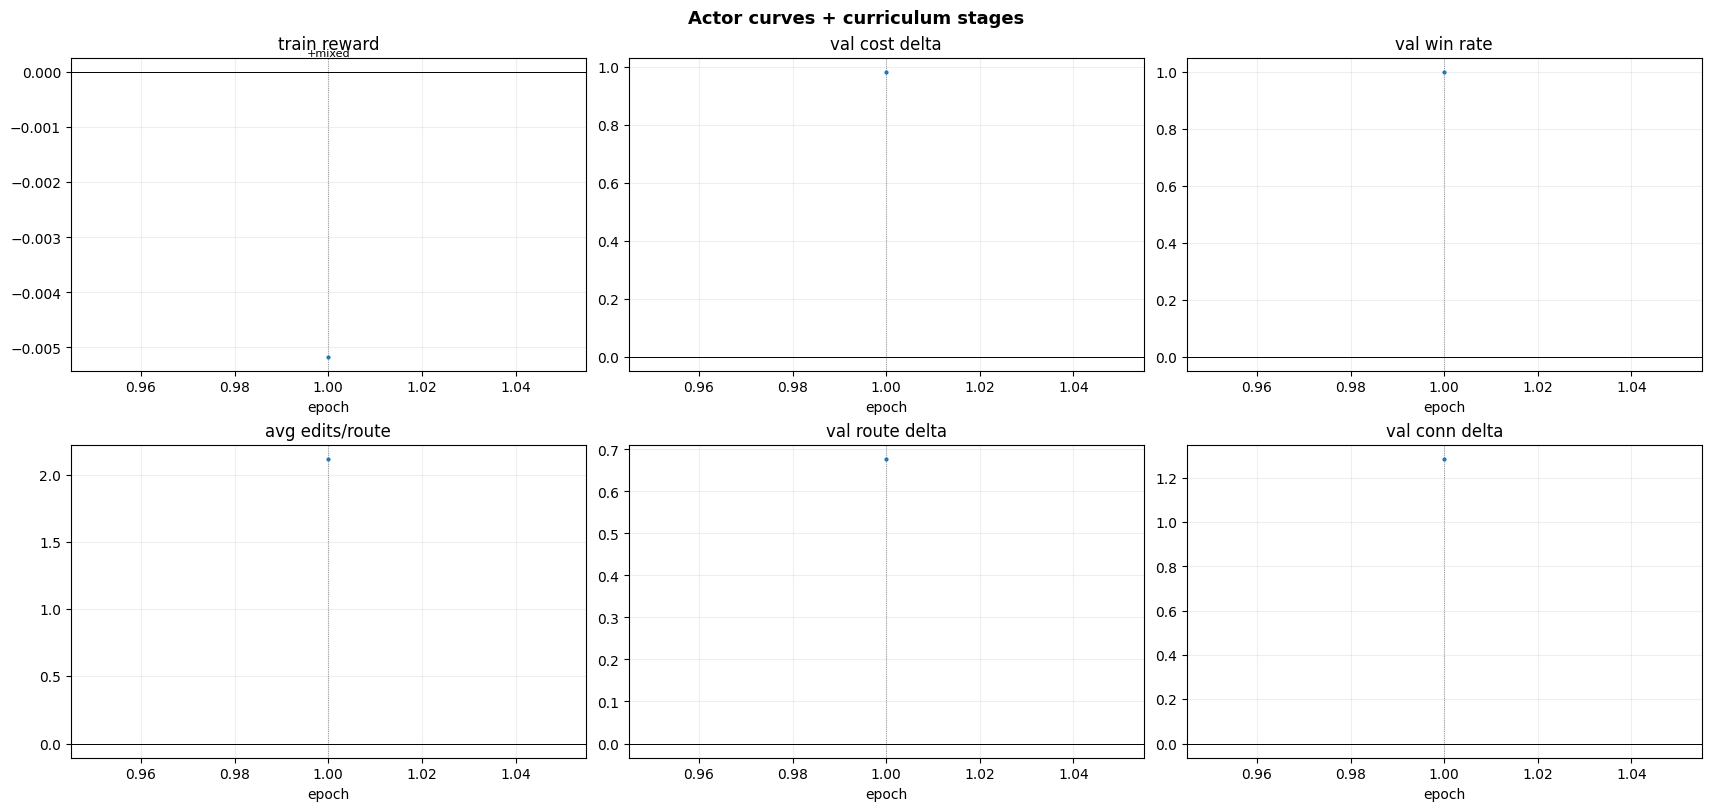

[tensorboard] 6 scalar series (1 epochs) -> D:\PythonProjects\connectpt\artifacts\lc_improvement_outputs\tensorboard\TEMP_smoke_edit_scratch
[tensorboard] launch:  tensorboard --logdir "D:\PythonProjects\connectpt\artifacts\lc_improvement_outputs\tensorboard"


In [10]:
if suite.run.training:
    from connectpt.routes_generator.paper_experiments.training_lc import (
        stitch_history, plot_training_history)

    h, spans = stitch_history(cfg=train_cfg, history_df=history_df)
    spans = spans or stage_spans()
    shade = plot_training_history(h, spans, train_cfg)


## Critic diagnostics (per-component critic MSE / explained variance)

critic columns: ['train_critic_mse_mean', 'train_critic_explained_variance']


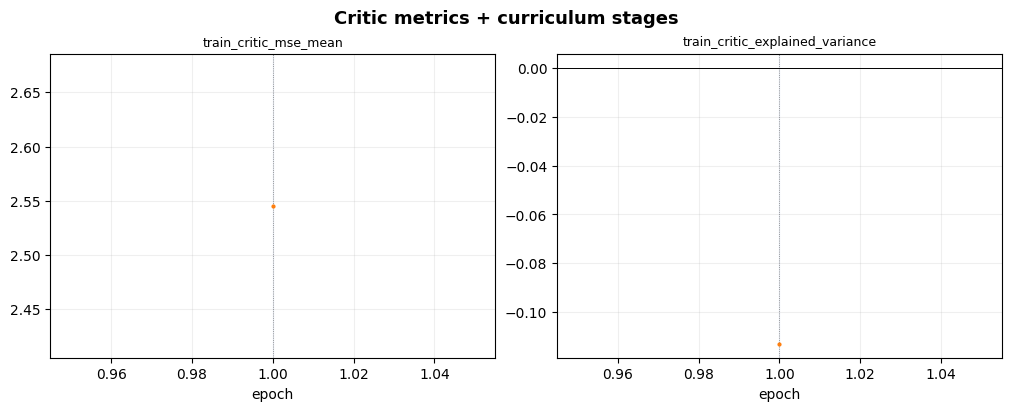

,epoch,curriculum_stage,train_critic_mse_mean,train_critic_explained_variance
0,1,+mixed,2.5453,-0.113


In [11]:
if suite.run.training:
    from connectpt.routes_generator.paper_experiments.training_lc import plot_critic_metrics
    crit_table = plot_critic_metrics(h, shade)
    if crit_table is not None:
        display(crit_table)


## Evaluate balanced policy by tier

The table reports before/after route-level redundancy, `ATT`, `RTT`,
connectivity, and demand percentages by transfer bucket (`d0`, `d1`, `d2`,
`d_un`). `Adj(current, seed)` remains available only in the example plots.

In [12]:
# Standalone balanced eval: rebuild model+cost from the checkpoint (always fresh),
# then evaluate per tier (cfg-driven). Visual examples are persisted by the library.
if suite.run.training:
    from connectpt.routes_generator.paper_experiments.training_lc import (
        balanced_eval_by_tier, save_visual_examples)
    from connectpt.routes_generator.core.checkpoints import CheckpointStore

    _, cost_obj, model, _, best_model_path = build_edit_model_and_cost(
        run_name=train_cfg.run.name, device=device,
        vary_weights=bool(train_cfg.cost.variable_weights),
        adj_weight=float(train_cfg.adjustment_degree_weight))
    if not best_model_path.exists():
        raise FileNotFoundError(f"No trained checkpoint at {best_model_path}. Train first.")
    CheckpointStore.load_model_weights(model, best_model_path, map_location=device)
    model.eval()

    eval_df, visual_examples = balanced_eval_by_tier(
        train_cfg, model=model, cost_obj=cost_obj, device=device,
        graphs=graphs, seed_routes=seed_routes, val_by_tier=val_by_tier)
    display(eval_df)
    save_table(eval_df, f"{train_cfg.run.name}_eval_by_tier", prefix=suite.output_prefix)
    save_visual_examples(train_cfg, visual_examples)
    print("ATT/RTT/CONN are minutes; d0/d1/d2/d_un are demand percentages by transfer bucket.")


eval balanced/copy_full:   0%|          | 0/1 [00:00<?, ?it/s]

eval balanced/copy_boundary:   0%|          | 0/1 [00:00<?, ?it/s]

eval balanced/copy_mixed:   0%|          | 0/1 [00:00<?, ?it/s]

eval balanced/covered_dup:   0%|          | 0/1 [00:00<?, ?it/s]

eval balanced/lc_clean:   0%|          | 0/1 [00:00<?, ?it/s]

,tier,n,redun_before,redun_after,ATT_before,ATT_after,RTT_before,RTT_after,CONN_before,CONN_after,d0_before,d0_after,d1_before,d1_after,d2_before,d2_after,d_un_before,d_un_after
0,copy_full,1,0.4944,0.3145,33.6527,25.4504,855.4302,1103.8958,50.1154,44.1193,15.1906,26.6901,22.3131,27.3409,17.1651,7.7213,45.3312,38.2477
1,copy_boundary,1,0.4425,0.3490,34.0756,32.4772,1429.8064,1864.6115,41.1974,36.0810,26.4297,26.2866,41.9752,38.1472,14.1698,18.8214,17.4253,16.7448
2,copy_mixed,1,0.6124,0.5185,39.5784,42.3836,1467.7241,1538.8580,59.2023,42.9859,28.5125,32.3307,33.2580,38.9478,10.5997,20.1449,27.6298,8.5766
3,covered_dup,1,0.5038,0.3673,33.2972,30.9034,1607.6239,1741.7264,36.4559,30.3298,30.2938,30.7438,40.0865,50.1405,18.8449,18.1384,10.7749,0.9773
4,lc_clean,1,0.2688,0.4255,31.9812,27.1205,918.5844,1289.4919,31.7637,27.2771,22.5650,31.2372,36.2453,45.0137,26.0986,21.5826,15.0912,2.1665


[results] table (5 rows) -> D:\PythonProjects\connectpt\artifacts\results\TEMP_TEMP_smoke_edit_scratch_eval_by_tier.csv
[eval] saved visual_examples -> D:\PythonProjects\connectpt\artifacts\lc_improvement_outputs\TEMP_smoke_edit_scratch_visual_examples.pt
ATT/RTT/CONN are minutes; d0/d1/d2/d_un are demand percentages by transfer bucket.


## Visual validation examples

For the balanced preference vector, show one seed and the corresponding edited
network from every tier.  The right-hand panels emphasize removed and added
segments relative to the corrupted seed.

render tiers:   0%|          | 0/5 [00:00<?, ?it/s]

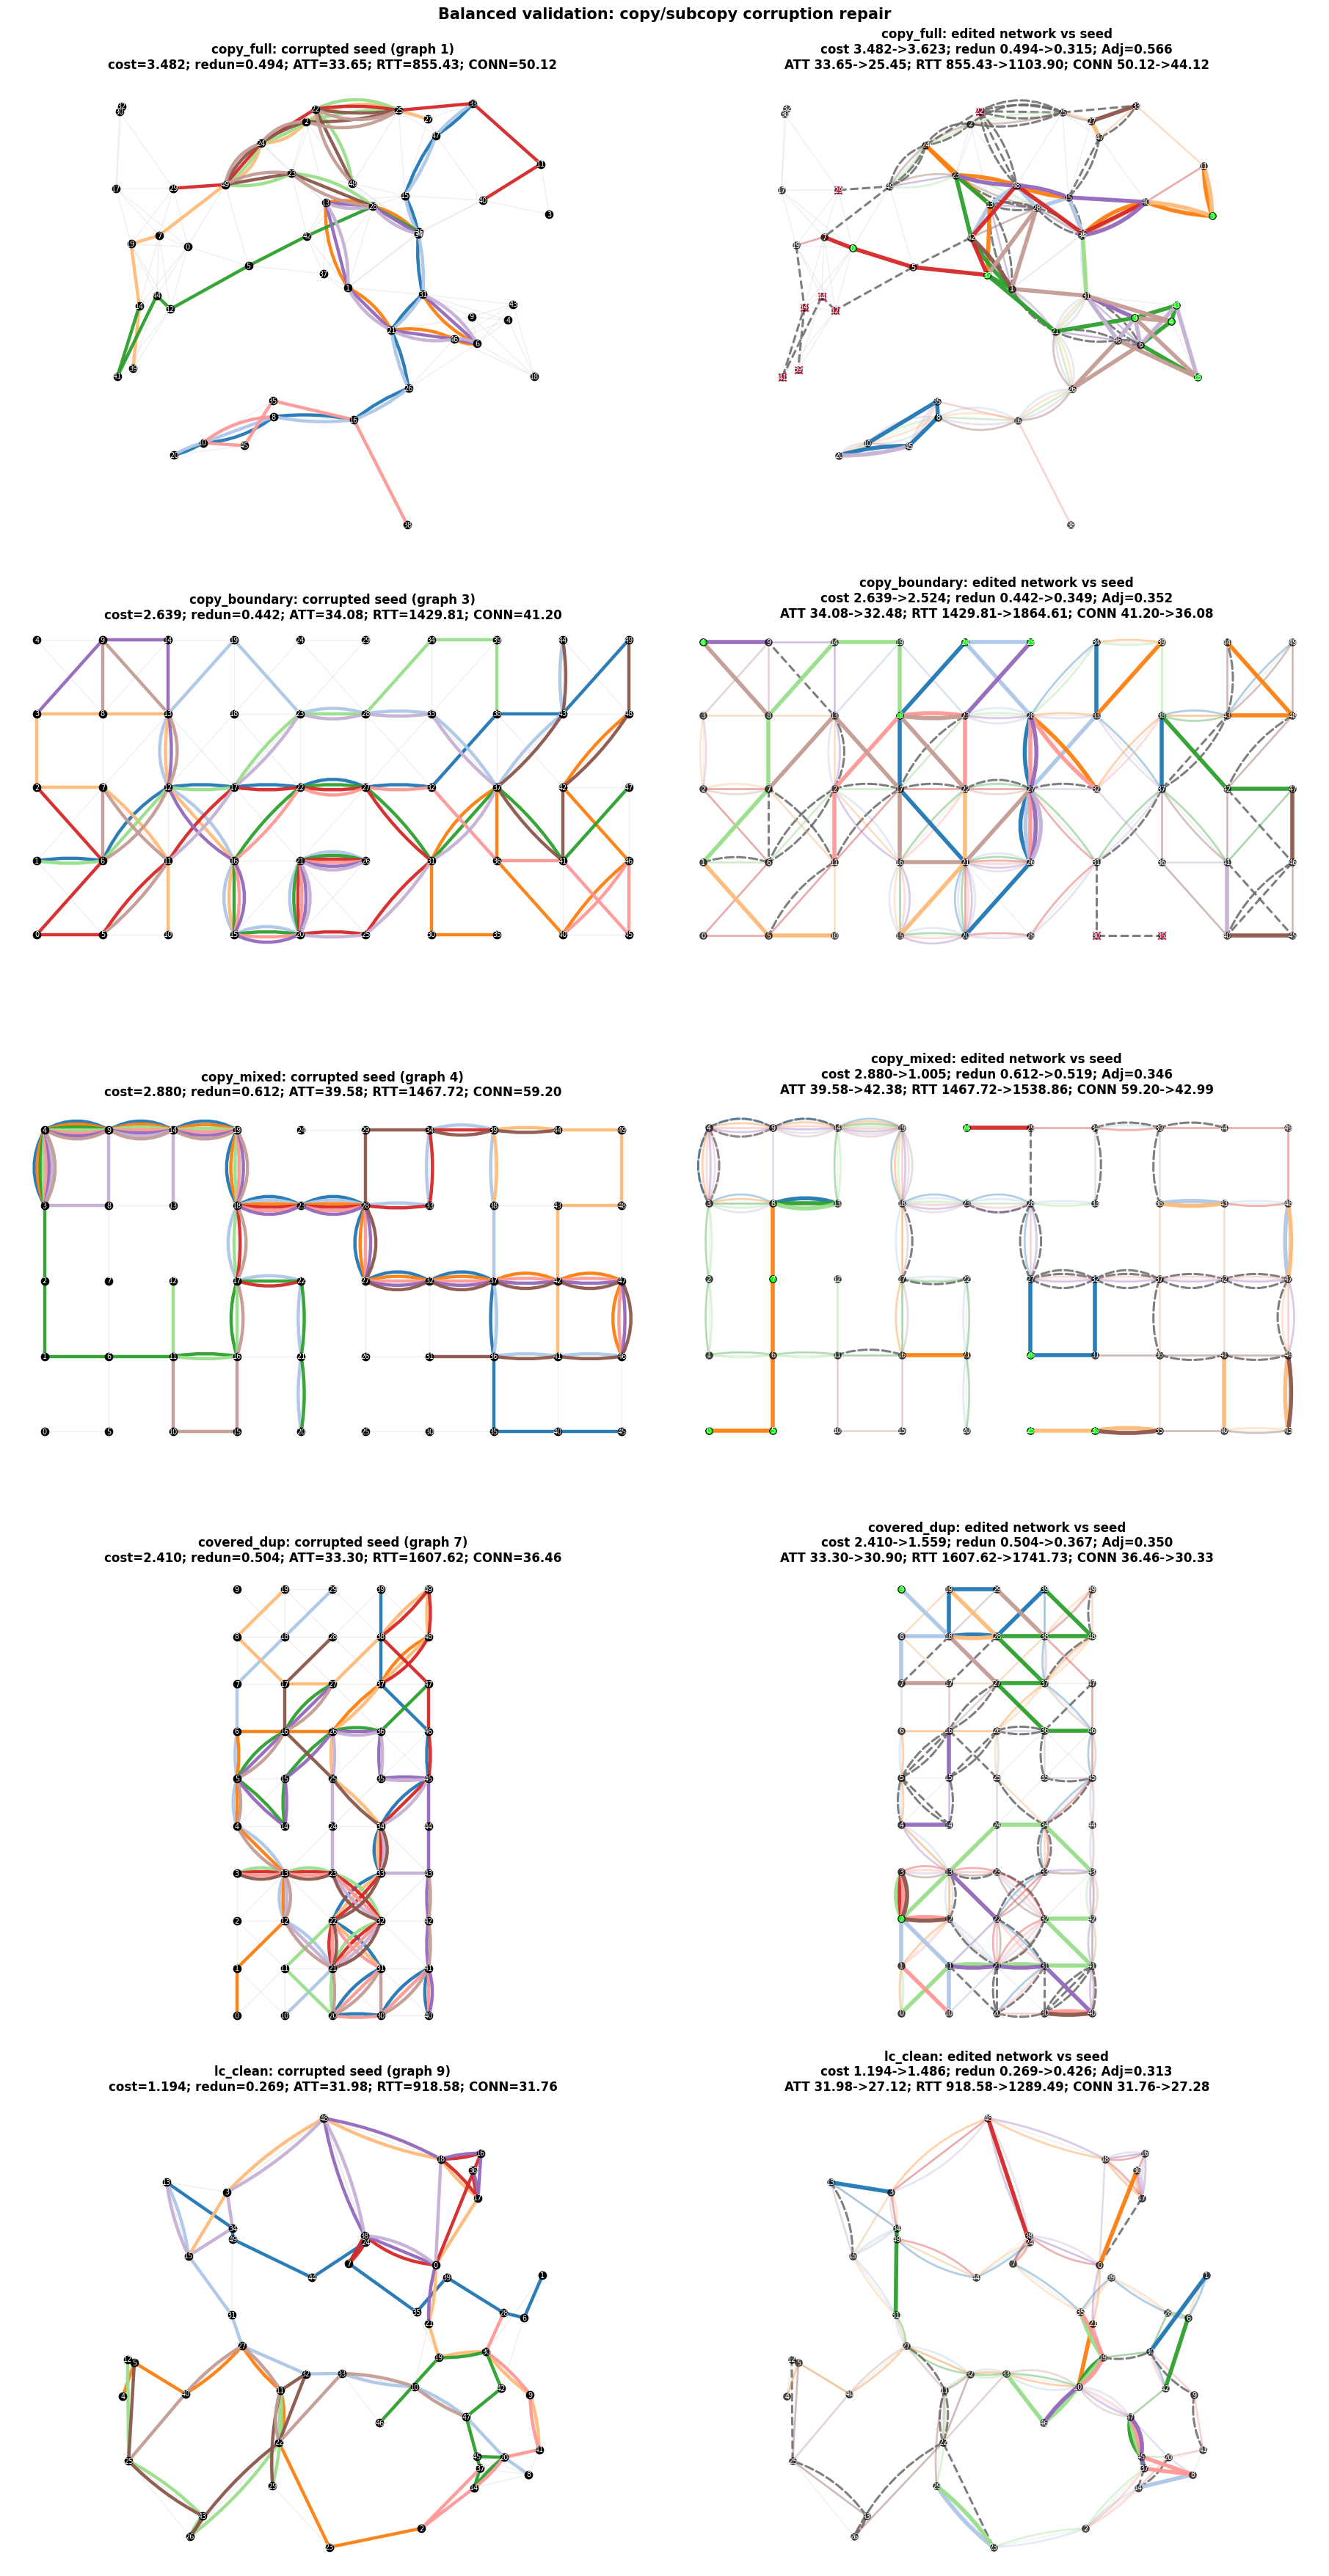

In [13]:
if suite.run.training:
    from connectpt.routes_generator.paper_experiments.training_lc import (
        plot_balanced_examples, load_visual_examples)
    visual_examples = load_visual_examples(train_cfg)
    plot_balanced_examples(visual_examples, graphs, list(train_cfg.curriculum.tiers))


## Post-training convergence: RPC + type2 vs RPC + trim/extend (Mumford1, 100 iters)

Right after PART 1 training, run two of the 5-model BCO variants -- random
path-combiner (RPC) rebuild paired with the hand-designed `type2` edit vs the
freshly trained `trim/extend` edit bee -- on Mumford1 for 100 BCO iterations
(balanced alpha=0.5, adjustment penalty off) and plot the convergence history.

[post-train] edit bee model <- TEMP_smoke_edit_scratch.pt
[post-train] RPC + trim/extend  final=2.6051 best=2.6051 (12s)
[post-train] RPC + type2        final=2.8793 best=2.8793 (7s)


,model,final_cost,best_cost,iters,seconds
0,RPC + trim/extend,2.6051,2.6051,1,12.0
1,RPC + type2,2.8793,2.8793,1,7.2


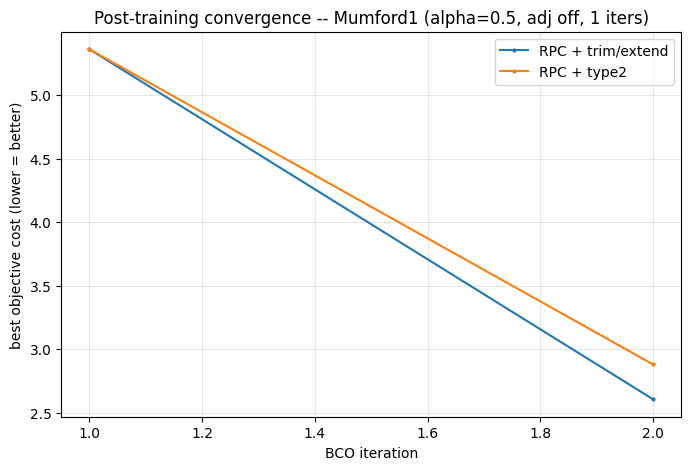

[results] table (2 rows) -> D:\PythonProjects\connectpt\artifacts\results\TEMP_posttrain_convergence_Mumford1.csv


In [14]:
# Post-training convergence: two 5-model BCO variants driven by the just-trained
# edit checkpoint (city/iters/alpha from train_cfg.report.post_train).
if suite.run.training:
    pass  # BENCHMARK_SPECS removed in M018 (specs now read from cfg/eval/ via benchmark_spec)
    from connectpt.routes_generator.baselines import load_benchmark_graph
    from connectpt.routes_generator.paper_experiments.training_lc import post_training_convergence

    conv_df, curves = post_training_convergence(
        train_cfg, best_model_path=best_model_path,
        load_benchmark_graph=load_benchmark_graph)
    display(conv_df)

    if curves:
        post = train_cfg.report.post_train
        fig, ax = plt.subplots(figsize=(8, 5))
        for label, curve in curves.items():
            ax.plot(range(1, len(curve) + 1), curve, marker="o", ms=2, label=label)
        ax.set_xlabel("BCO iteration")
        ax.set_ylabel("best objective cost (lower = better)")
        ax.set_title(f"Post-training convergence -- {post.city} "
                     f"(alpha={post.alpha}, adj off, {post.iters} iters)")
        ax.grid(alpha=0.3); ax.legend()
        plt.show(); plt.close(fig)
        curves_df = pd.DataFrame({k: pd.Series(v) for k, v in curves.items()})
        curves_df.index.name = "bco_iteration"
        save_table(curves_df.reset_index(), f"posttrain_convergence_{post.city}",
                   prefix=suite.output_prefix)
    else:
        print("[post-train] no convergence history captured")


---
# PART 2 - BCO experiments (E1-E6)

Uses the model trained above (`BEST_MODEL_PATH`). All baselines are re-run live on a single seed with small budgets.

## Configuration

`SMOKE=True` -> Mandl only, 1 seed, tiny iteration budgets (just checks the
pipeline builds tables/figures). `SMOKE=False` runs Mandl and Mumford0-3
with the 25-30 hour budgeted settings below.


In [15]:
# PART 2 experiment runtime is driven entirely by the suite profile (loaded above):
# selection + parameters live in cfg/experiments/suite*.yaml, outputs go to the
# suite's paper folder with its prefix. Nothing to configure here.
print("enabled experiments:", dict(suite.run))
print("cities:", list(suite.cities), "| output prefix:", repr(suite.output_prefix))


enabled experiments: {'training': True, 'clean_lc_baseline': True, 'e2_our_pareto': True, 'e2_5model': True, 'e2_route_viz': True, 'm0_nbco_variants': True, 'macsa': True, 'nsgaii_baselines': True, 'ekb_case_study': True, 'ekb_nbco': True, 'ekb_alpha_sweep': True}
cities: ['Mandl'] | output prefix: 'TEMP_'


## Shared PART-2 imports (paper sinks + metric helpers)

In [16]:
# Shared PART-2 helpers: the config-first run wrappers + the report renderer.
from connectpt.routes_generator.paper_experiments.paper_runs import (
    run_experiment, run_batch, save_paper)
from connectpt.routes_generator import render_report


## EKB case study

Load the Ekaterinburg instance, inspect its projected coordinates, and render the supplied seed routes as a regular matplotlib figure.


EKB coords: (703, 2) CRS EPSG:32641 lat (56.629, 56.9677) lon (60.2391, 60.9116)
EKB spec: {'city': 'EKB', 'n_routes': 67, 'min_route_len': 11, 'max_route_len': 54} | route stats: {'n_routes': 67, 'min_len': 11, 'max_len': 54, 'mean_len': 30.134328842163086, 'unique_stops': 592}
EKB connectivity: {'components': 2, 'isolated_nodes': [66], 'symmetric': True, 'cross_component_demand_pct': 0.0204}


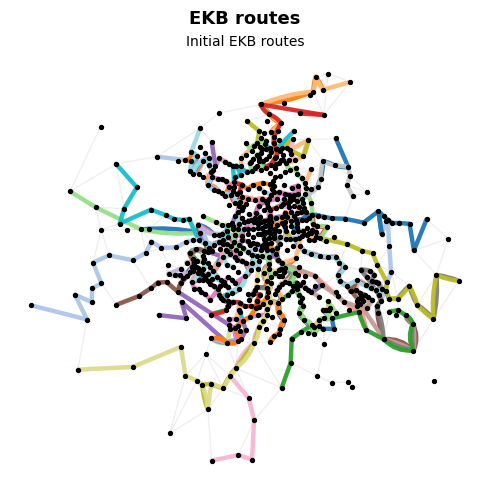

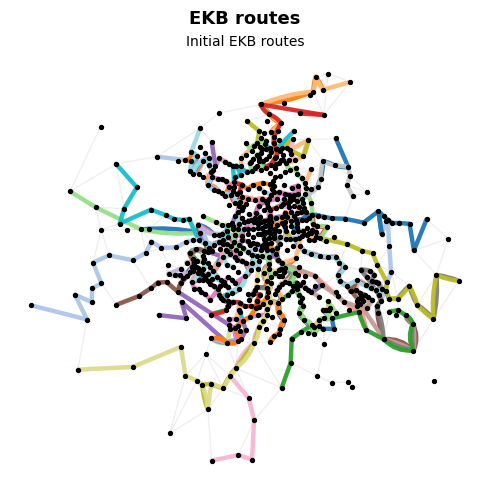

In [17]:
# EKB case study: load the instance + render its seed route network (geo/GIS).
from types import SimpleNamespace
from connectpt.routes_generator.data import EKBDataSource
from connectpt.routes_generator.reports import (network_connectivity_stats,
                                                route_stats, project_coords)
from connectpt.routes_generator.reports.ekb import EKB_COORD_CRS

if suite.run.ekb_case_study:
    instance = EKBDataSource().load()
    stats = route_stats(instance.init_routes)
    latlon = project_coords(instance.coords, EKB_COORD_CRS)
    print("EKB coords:", tuple(instance.coords.shape), "CRS", EKB_COORD_CRS,
          "lat", (round(float(latlon[:, 0].min()), 4), round(float(latlon[:, 0].max()), 4)),
          "lon", (round(float(latlon[:, 1].min()), 4), round(float(latlon[:, 1].max()), 4)))
    conn = network_connectivity_stats(instance.tensors, instance.init_routes)
    print("EKB spec:", instance.spec, "| route stats:", stats)
    print("EKB connectivity:", {"components": conn["n_components"],
          "isolated_nodes": conn["isolated_nodes"], "symmetric": conn["symmetric"],
          "cross_component_demand_pct": round(conn["cross_component_demand_pct"], 4)})
    seed_report = SimpleNamespace(run_name="EKB seed", table=pd.DataFrame(),
                                  routes={"Initial EKB routes": instance.init_routes},
                                  instance=instance, metadata={})
    for fig in render_report(seed_report, kind="gis", title="EKB seed").figures.values():
        display(fig)
else:
    print("[EKB case study] skipped (suite.run.ekb_case_study=False)")


### EKB NBCO GNN + trim/extend

Run our NBCO variant on the Ekaterinburg instance and draw before/after route sets in both plain and diff modes. Overlapping route edges are rendered as curved arcs so duplicate coverage stays visible instead of collapsing into one line.


In [18]:
# EKB NBCO (GNN rebuild + trim/extend) via the config-first runner + geo render.
if suite.run.ekb_nbco:
    ekb = run_experiment("ekb_case_study", suite, kind="gis", title="EKB NBCO")
    ekb.display()
else:
    print("[EKB NBCO] skipped (suite.run.ekb_nbco=False)")


KeyboardInterrupt: 

# EKB alpha sweep

Run only the Ekaterinburg alpha sweep with adjustment target 0.3. Results are written to a separate table and route dump so existing paper results are not overwritten.


In [19]:
# EKB alpha sweep = the alpha grid of the EKB NBCO run above; show its table.
if suite.run.ekb_nbco:
    display(ekb.table)
else:
    print("[EKB sweep] skipped (EKB NBCO not run)")


NameError: name 'ekb' is not defined

### EKB best solution (overwritten each run)

The best achieved EKB network (BCO incumbent) is written to fixed-name `artifacts/paper_results/final_ekb_best_solution.{csv,_routes.pt}` and overwritten on every run.

In [ ]:
# Save the single best EKB solution (min-cost sweep row) to a fixed stem.
if suite.run.ekb_nbco and not ekb.artifact.table.empty:
    art = ekb.artifact
    best = art.table.loc[art.table["cost"].idxmin()]
    key = f'{best["method"]} a={best["alpha"]} t={best["adj_target"]}'
    best_row = art.table[art.table["alpha"] == best["alpha"]].round(6)
    save_paper(
        suite, "ekb_best", table=best_row,
        routes={"Initial EKB routes": as_route_tensor(art.instance.init_routes),
                key: as_route_tensor(art.routes[key])},
        coords=art.instance.coords, street_adj=art.instance.street_adj,
        meta={"city": "EKB", "best_method": key})
    display(best_row)
    print(f"[EKB best] saved -> ekb_best (method={key})")
else:
    print("[EKB best] skipped (EKB NBCO not run)")


In [ ]:
# Mumford0 NBCO variants (m0) removed in the M018 config cleanup -- it was not a
# paper artifact (0 references outside this deprecated notebook). Section dropped.
print("[m0] removed in M018 config cleanup (not a paper artifact)")

## E2 - Pareto fronts on RTT x WMC (Mumford0, covered_dup tier)

Both panels run on **Mumford0** from the **covered_dup** init tier (removable
redundancy), optimizing `alpha*RTT + (1-alpha)*WMC + adj(|.-target|)` with
`use_weighted_connectivity=True`. `alpha` = `route_time_weight` (so alpha=1 ->
pure RTT, alpha=0 -> pure WMC).

- **Fig 1 (our model):** RTT x WMC Pareto front of `GNN + trim/extend`, swept
  over `alpha` x `adj_target` (one curve per target).
- **Fig 2 (4-model comparison):** `{GNN, RPC} x {trim/extend, type2}`, alpha-
  swept at a fixed `adj_target=ADJ_TARGET` -> shows the trim/extend
  bee's contribution to the RTT x WMC front.

In [ ]:
# E2 city label (read from the config, for the printed header only).
from connectpt.routes_generator import load_experiment
e2_city = load_experiment("table4_fig4_our_pareto").data.city
print(f"[E2] city={e2_city} | our_pareto={suite.run.e2_our_pareto} 5model={suite.run.e2_5model}")

[E2] city=Mumford1 | our_pareto=True 5model=True


In [ ]:
# E2 Our-NBCO Pareto sweep (alpha x adj_target) on Mumford1 -- config-first.
if suite.run.e2_our_pareto:
    e2 = run_experiment("table4_fig4_our_pareto", suite)
    e2.display()
else:
    print("[E2] our-model Pareto sweep skipped (suite.run.e2_our_pareto=False)")

In [ ]:
# E2 5-model RTT x WMC comparison on Mumford1 (adjustment off) -- config-first batch.
if suite.run.e2_5model:
    e2_5model = run_batch("table5_fig5_5model", suite)
    e2_5model.display()
else:
    print("[E2] 5-model alpha sweep skipped (suite.run.e2_5model=False)")


### E2 Route Visualisation

Draw selected `alpha x adj_target` route sets from the E2 our-model sweep. The first grid shows the route sets directly; the second grid highlights changes against the LC initial network.

In [ ]:
# E2 route panels from the in-memory run artifact (config-first render, no reload).
if suite.run.e2_our_pareto:
    for fig in render_report(e2.artifact, kind="network",
                             title=f"E2 {e2_city}: our-model routes").figures.values():
        display(fig)
else:
    print("[E2 route viz] skipped (E2 our-pareto not run)")


## E1 narrow -- neural BCO vs Our NBCO alpha sweep

Runs only two methods on every benchmark city (`Mandl`, `Mumford0`, `Mumford1`, `Mumford2`, `Mumford3`):
`neural BCO` and `Our NBCO (GNN rebuild + trim/extend)`. For each method we run
`alpha in {0, 0.5, 1}` with `adjustment_degree_target=0.5` and 100 BCO iterations.

All SA / GA / HH / heuristic BCO / NSGA-II / trim-only branches are disabled here. Tables are saved as
`paper_results/final_main_unified_<city><E1U_TABLE_SUFFIX>.csv` and a combined table as
`final_main_unified_comparison<E1U_TABLE_SUFFIX>.csv`.


In [ ]:
# E1 narrow: neural BCO vs Our NBCO alpha sweep -- one config-first batch per city.
e1_runs = {}
for city in suite.e1.cities:
    print(f"=== {city} E1 narrow: neural BCO + Our NBCO ===", flush=True)
    e1 = run_batch("table3_nbco_vs_our", suite, city=city)
    e1.display()
    e1_runs[city] = e1

if e1_runs:
    unified_df = pd.concat(
        [r.artifact.table.drop(columns=["run"]) for r in e1_runs.values()],
        ignore_index=True).round(3)
    display(unified_df)
    save_paper(suite, "e1_unified_comparison", table=unified_df)
else:
    print("E1 narrow skipped: no cities configured (suite.e1.cities is empty).")


### Route visualisation (unified run: RTT + WMC + adj for all methods)

Drawn from the **unified** dumps (`final_main_unified_<city>`). Layout: OD demand -> init -> methods (plain & diff vs init), plus a focused 1x4 (our routes / init / neural-BCO diff / our-NBCO diff).

In [ ]:
# E1 route panels from a run artifact (config-first render, no dump reload).
if e1_runs:
    viz_city = next(iter(e1_runs))
    for run_art in e1_runs[viz_city].artifact.artifacts:
        for fig in render_report(run_art, kind="network").figures.values():
            display(fig)
else:
    print("[route viz] skipped: no E1 runs")


## MACSA Table B -- paper routes + Our NBCO alpha sweep

This section replaces the old generic MACSA probe with the exact Mandl-8 Table-B workflow used for the paper figures. It reads the fixed route sets from `datasets/MACSA_data/mandl_8/routes_*.txt`, scores them with the same E1-style metric plumbing, then runs Our NBCO from the original network with `adjustment_degree_target = adj(MACSA, original)`.

Outputs:
- `final_macsa_mandl8_alpha_sweep_iter100.*`: Our NBCO alpha sweep, `alpha=0.0..1.0` step `0.1`, 100 BCO iterations per run.
- `final_macsa_mandl8_tableb.*`: Table-B paper methods plus the best Our NBCO sweep solution that beats MACSA on both RTT and WMC. The old cap-mode row is intentionally not included.


In [ ]:
# MACSA Table-B case study as ONE config-first call: score the fixed Table-B routes,
# run the Our-NBCO alpha sweep, pick the best solution beating MACSA, draw the grids.
from connectpt.routes_generator.paper_experiments.macsa_run import run_macsa_table_b

if suite.run.macsa:
    macsa = run_macsa_table_b(suite)
    macsa.display()
else:
    print("MACSA Table-B skipped (suite.run.macsa=False)")
